|<div style="width:330px"><img src="https://www.ufz.de/static/custom/weblayout/DefaultInternetLayout/img/logos/ufz_transparent_de_blue.png" width="300"/></div>|<div style="width:290px"><img src="https://discourse.opengeosys.org/uploads/default/original/1X/a288c27cc8f73e6830ad98b8729637a260ce3490.png" width="290"/></div>|<div style="width:330px"><img src="https://github.com/nagelt/Teaching_Scripts/raw/9d9e29ecca4b04eaf7397938eacbf116d37ddc93/Images/TUBAF_Logo_blau.png" width="300"/></div>|
|---|---|--:|

Dr. Mehran Ghasabeh
\
Prof. Dr. Thomas Nagel

*Chair of Soil Mechanics and Foundation Engineering
\
Geotechnical Institute
\
Technische Universität Bergakademie Freiberg*

https://tu-freiberg.de/en/soilmechanics

# Heated Tunnel Problem (HE/FE Experiment)
## Coupled THM Simulation Using the Thermo-Richards-Mechanics (TRM) Process

### 1. Introduction

In the context of the deep geological disposal of high-level radioactive waste, numerical tools play a critical role in evaluating and predicting the long-term behaviour of repository systems over temporal and spatial scales that cannot be fully addressed by laboratory or in-situ experiments. The relevant physical processes occurring throughout the service life of a repository can be translated into mathematical formulations based on appropriate physical models. These processes can then be investigated using highly coupled numerical models capable of simulating the thermo-hydro-mechanical (THM) response of the geological disposal system based on Biot’s consolidation theory [2, 3]. In this example, we simulate the near-field of a heat-emitting tunnel motivated by the FE (Full-scale Emplacement) heater experiment at the Mont Terri rock laboratory, following the model description reported in the work of of Pitz et al. [1]. The problems is solved with the **THERMO_RICHARDS_MECHANICS (TRM)** process of OpenGeoSys in its fully and partially saturated form. Two fully saturated runs differing only in the **bedding orientation** (0° = horizontal vs. 90° = vertical bedding
planes) quantify the effect of the clay anisotropy; the partially saturated model of Section 8 uses the legacy 90° orientation.

A quarter of the 50 m × 50 m domain is modelled under plane-strain conditions. Two materials are present: a **granular bentonite buffer** (GBM)
filling the tunnel annulus between the heater surface ($r = 0.525$ m) and the tunnel wall ($R = 1.24$ m), and the surrounding **Opalinus Clay** host rock (OPA) with orthotropic elasticity and anisotropic permeability and thermal conductivity aligned with the bedding. The heater itself is not discretized:
it is represented by a heat-flux (Neumann) boundary condition of
$89\,\mathrm{W\,m^{-2}}$ on the inner arc. All outer boundaries are rollers,
the heater surface is fixed, and all hydraulic and remaining thermal
boundaries are natural (no flow).

The problem is solved with the **THERMO_RICHARDS_MECHANICS (TRM)** process of
OpenGeoSys in its fully saturated form, using the material properties,
boundary conditions, and initial conditions of the legacy THM project
(`legacy_thm/tunnel_ortho_LTRB_90_roller_SparseLU.prj`): saturation and
relative permeability are constant at one, so the Richards formulation
coincides with single-phase hydro-thermo-mechanics. The displacement is
discretized with quadratic (order-2) elements, pressure and temperature
with linear elements. Monitored effects are the thermal pressurisation of
the pore water, the temperature field around the heater, and the
resulting deformation. 

In [1]:
# Resolve the example directory when launched from JupyterLab or the repo root.
from pathlib import Path
import os
import sys

example_name = '03_TRM_Heated_Tunnel_FE_Experiment'
example_dir = Path.cwd()
if not (example_dir / 'mesh_tunnel_trm.py').is_file():
    example_dir = example_dir / example_name
if not example_dir.is_dir():
    raise FileNotFoundError(f"Example directory not found: {example_dir}")
os.chdir(example_dir)
if str(example_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(example_dir.resolve()))
print(f"Example directory: {Path.cwd()}")


Example directory: /home/mehran/Desktop/OGS_Course_2026/03_TRM_Heated_Tunnel_FE_Experiment


In [2]:
%matplotlib inline
import os
from pathlib import Path
import shutil

import gmsh
import matplotlib.pyplot as plt
import numpy as np
import ogstools as ot
from ogstools.variables import Scalar
import pyvista as pv
from mesh_tunnel_trm import MeshGenerator
from prj_trm import PrjGenerator

# --- Unified course plotting style (identical in all three course notebooks) ---
# Color identifies the entity (model, monitoring point, angle, time);
# linestyle identifies the solution type: simulation = solid (or markers
# for sampled points), analytical/reference = dashed (black if unambiguous).
# Continuous fields use the perceptually uniform "viridis" colormap.
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
             "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
CMAP_FIELD = "viridis"
plt.rcParams.update({
    "font.size": 13,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=OKABE_ITO),
})


def plot_contours(mesh, variables, shape=None, zoom=10.0, cmap=CMAP_FIELD,
                  show_edges=False):
    """Kirsch-style contour panels: one ot.plot.contourf per variable."""
    rows, cols = shape if shape is not None else (1, len(variables))
    fig, ax = plt.subplots(
        rows, cols,
        figsize=(6.5 * cols, 5.5 * rows),
        gridspec_kw={"wspace": 0.4, "hspace": 0.3},
    )
    axes = np.atleast_1d(ax).flatten()
    for axis, variable in zip(axes, variables):
        ot.plot.contourf(
            mesh,
            variable,
            fig=fig,
            ax=axis,
            fontsize=12,
            cb_labelsize=12,
            cmap=cmap,
            show_edges=show_edges,
        )
        if zoom is not None:
            axis.set_xlim(0, zoom)
            axis.set_ylim(0, zoom)
    return fig, axes


def plot_mechanics(ms):
    """2x2 mechanics panels: |u|, effective mean stress, tau_oct, sigma_m."""
    # Copy: avoid mutating the cached mesh of the series.
    last = ms.mesh(-1).copy()
    last.point_data["pressure"] = last.point_data["pressure_interpolated"]

    # Effective mean stress (tension positive, Biot coefficient = 1).
    sigma_m = last["sigma"][:, :3].mean(axis=1)
    last.point_data["sigma_m_eff"] = sigma_m + last["pressure"]
    effective_mean_stress = Scalar(
        data_name="sigma_m_eff",
        data_unit="Pa",
        output_unit="MPa",
        output_name="effective_mean_stress",
        symbol="\\sigma'_m",
        bilinear_cmap=True,
    )

    plot_contours(
        last,
        [
            ot.variables.displacement,
            effective_mean_stress,
            ot.variables.stress.octahedral_shear,
            ot.variables.stress.tensor_mean,
        ],
        shape=(2, 2),
    )

# --- Save every figure of this notebook as PDF to Outputs/ (identical in all
# three course notebooks). Figures are written automatically, either when
# they are shown (plt.show) or when the cell that created them finishes.
# Files are numbered in order of creation and named after the figure title;
# the folder is emptied each time this cell runs.
import re
from IPython import get_ipython

OUTPUT_DIR = Path("Outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
for _old_pdf in OUTPUT_DIR.glob("*.pdf"):
    _old_pdf.unlink()
_figure_count = 0


def _figure_name(fig):
    """File name stem from the figure title, or from the axis labels."""
    ax = fig.axes[0]
    candidates = [fig.get_suptitle(), *(a.get_title() for a in fig.axes),
                  f"{ax.get_ylabel()} vs {ax.get_xlabel()}"]
    text = next((t for t in candidates if t.strip(" vs")), "figure")
    text = re.sub(r"[\\$^{}]", "", text)
    return re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()[:60] or "figure"


def save_open_figures(*args):
    """Write all open matplotlib figures that were not saved yet to Outputs/."""
    global _figure_count
    for num in plt.get_fignums():
        fig = plt.figure(num)
        if fig.axes and not getattr(fig, "_saved_to_outputs", False):
            _figure_count += 1
            fig.savefig(OUTPUT_DIR / f"{_figure_count:02d}_{_figure_name(fig)}.pdf",
                        bbox_inches="tight")
            fig._saved_to_outputs = True


if not getattr(plt.show, "_saves_figures", False):
    _plt_show = plt.show

    def _show_and_save(*args, **kwargs):
        save_open_figures()
        return _plt_show(*args, **kwargs)

    _show_and_save._saves_figures = True
    plt.show = _show_and_save

if get_ipython() is not None:  # run before the inline backend closes figures
    _callbacks = get_ipython().events.callbacks["post_execute"]
    _callbacks[:] = [c for c in _callbacks if getattr(c, "__name__", "") != "save_open_figures"]
    _callbacks.insert(0, save_open_figures)


### 2. Model parameters

All physical parameters of the benchmark (Table 8 of the reference paper,
fully saturated TRM-S case) are defined here in one place and passed
explicitly to the mesh generator (`MeshGenerator`) and the project generator
(`PrjGenerator`).

In [3]:
# --- Geometry (quarter model of the 50 m x 50 m HE domain) ---
HEATER_RADIUS = 0.525  # m, inner arc (heater surface)
TUNNEL_RADIUS = 1.24  # m, outer arc (tunnel wall = buffer/rock interface)
WIDTH = 25.0  # m
HEIGHT = 25.0  # m
WIDTH_M = 12.5  # m, intermediate mesh box
HEIGHT_M = 12.5  # m, intermediate mesh box
ELEMENT_ORDER = 2  # quadratic displacement, linear pressure/temperature
N_TRANSFINITE = 15  # nodes per mesh block edge
N_RING = 8  # radial nodes across the buffer ring

# --- Simulation cases: all are generated and run ---
# saturated_0 / saturated_90:  S_L = 1 everywhere (single-phase THM limit),
#                              differing only in the bedding orientation of
#                              the clay (0 = horizontal, 90 = vertical
#                              bedding planes; 90 is the legacy setup)
# partially_saturated:         van Genuchten retention + water-vapour
#                              diffusion; the buffer starts at high suction
#                              (S_L ~ 0.23); bedding at 90 degrees
CASES = {
    "saturated_0": {"saturation_model": "saturated", "bedding_angle": 0},
    "saturated_90": {"saturation_model": "saturated", "bedding_angle": 90},
    "partially_saturated": {
        "saturation_model": "partially_saturated",
        "bedding_angle": 90,
    },
}

# --- Liquid phase (water), shared by both media ---
LIQUID = {
    "specific_heat_capacity": 4184.0,  # J/(kg K)
    "thermal_conductivity": 0.63,  # W/(m K)
    "density_reference": 1000.0,  # kg/m^3
    "density_reference_temperature": 293.15,  # K
    "density_slope_temperature": -4.0e-4,  # 1/K
    "density_reference_pressure": 1.0e5,  # Pa
    "density_slope_pressure": 5.0e-10,  # 1/Pa
    "thermal_expansivity": 4.0e-4,  # 1/K
    "viscosity": 1.0e-3,  # Pa s
}
# The partially saturated case uses the DECOVALEX Task C water constants
# (the saturated case keeps the legacy values above).
LIQUID_UNSATURATED = {
    **LIQUID,
    "specific_heat_capacity": 4181.3,  # J/(kg K)
    "density_reference_temperature": 273.15,  # K
    "density_slope_pressure": 4.6511627906976743e-10,  # 1/Pa
}

# --- Granular bentonite buffer (GBM), medium 0, isotropic ---
BENTONITE = {
    "density": 2227.2,  # kg/m^3 (solid)
    "specific_heat_capacity": 800.0,  # J/(kg K)
    "thermal_conductivity": 1.2,  # W/(m K), saturated
    "thermal_expansivity": 3.0e-6,  # 1/K
    "permeability": 3.5e-20,  # m^2
    "porosity": 0.331,
    "youngs_modulus": 18.0e6,  # Pa
    "poissons_ratio": 0.35,
    # -- used by the partially saturated model only --
    "tortuosity": 0.8,
    "thermal_conductivity_dry": 0.35,  # W/(m K)
    "thermal_conductivity_saturated": 1.2,  # W/(m K)
    "vg_p_b": 28.6e6,  # Pa, van Genuchten gas entry pressure
    "vg_exponent": 0.5,  # m = 1 - 1/n with n = 2.0
    "residual_liquid_saturation": 0.0,
    "residual_gas_saturation": 0.0,
    "minimum_relative_permeability": 1e-6,
    "initial_pressure": -123.0e6,  # Pa <=> S_L(t=0) = 0.23
}

# --- Opalinus Clay (OPA), medium 1, orthotropic (local system e0=(0,1)) ---
CLAY = {
    "density": 2689.66,  # kg/m^3 (solid)
    "specific_heat_capacity": 995.0,  # J/(kg K)
    # thermal conductivity is given in the local basis (e0, e1) and is
    # rotated with the bedding by OGS; the permeability is a global
    # tensor, its per-case ordering is assembled in the project cell
    "thermal_conductivity": "1.3 0 0 2.4",  # W/(m K), (e0, e1)
    "thermal_expansivity": 1.5e-5,  # 1/K
    "permeability_perp": 1.0e-20,  # m^2
    "permeability_para": 5.0e-20,  # m^2
    "porosity": 0.13,
    "youngs_moduli": "4.000e+09 8.000e+09 8.000e+09",  # Pa
    "poissons_ratios": "0.25 0.35 0.35",
    "shear_moduli": ["3.5e9", "8e9/(2*(1+0.35))", "8e9/(2*(1+0.35))"],  # Pa
    # -- used by the partially saturated model only --
    "tortuosity": 0.8,
    "vg_p_b": 20.0e6,  # Pa
    "vg_exponent": 0.6,  # m = 1 - 1/n with n = 2.5
    "residual_liquid_saturation": 0.0,
    "residual_gas_saturation": 0.0,
    "minimum_relative_permeability": 1e-6,
    "initial_pressure": 2.0e6,  # Pa (in-situ pore pressure)
}

BIOT_COEFFICIENT = 1.0

# --- Loads, initial conditions (as in the legacy project) ---
HEATER_FLUX = 89.0  # W/m^2 on the heater surface (arc_inner)
INITIAL_TEMPERATURE = 288.15  # K (15 degC)
INITIAL_PRESSURE = 0.0  # Pa
INITIAL_STRESS = "0 0 0 0"  # Pa (xx yy zz xy)

# --- Time discretization (5 years of heating) ---
T_END = 157680000.0  # s
INITIAL_DT = 0.1  # s
MINIMUM_DT = 0.01  # s
MAXIMUM_DT = 1576000.0  # s
NUMBER_ITERATIONS = "2 4 6 7 8 9 10 12 16"
MULTIPLIER = "1.5 1.35 1.35 1.25 1.1 1.01 0.75 0.5 0.25"
RELTOLS = "1e-6 1e-6 1e-6 1e-6"  # T, p, u_x, u_y

### 3. Solver settings

Nonlinear and linear solver configuration passed to `PrjGenerator`. The
linear solver is chosen by name from the presets below.

In [4]:
# Nonlinear solver (Newton).
NONLINEAR_MAX_ITER = 20

# Linear solver: pick one preset by name.
LINEAR_SOLVER = "SparseLU + scaling"

LINEAR_SOLVER_PRESETS = {
    "BiCGSTAB + ILUT": {
        "linear_solver_type": "BiCGSTAB",
        "preconditioner_type": "ILUT",
        "linear_max_iter": 10000,
        "linear_error_tolerance": 1e-20,
        "linear_solver_scaling": False,
    },
    "GMRES + ILUT": {
        "linear_solver_type": "GMRES",
        "preconditioner_type": "ILUT",
        "linear_max_iter": 10000,
        "linear_error_tolerance": 1e-20,
        "linear_solver_scaling": False,
    },
    # Direct solver: no preconditioner/iterations; optional diagonal
    # scaling (needs an OGS build with Eigen unsupported modules).
    "SparseLU + scaling": {
        "linear_solver_type": "SparseLU",
        "preconditioner_type": None,
        "linear_max_iter": None,
        "linear_error_tolerance": None,
        "linear_solver_scaling": True,
    },
    "SparseLU": {
        "linear_solver_type": "SparseLU",
        "preconditioner_type": None,
        "linear_max_iter": None,
        "linear_error_tolerance": None,
        "linear_solver_scaling": False,
    },
}

linear_solver_options = LINEAR_SOLVER_PRESETS[LINEAR_SOLVER]
print(f"Linear solver: {LINEAR_SOLVER} -> {linear_solver_options}")

Linear solver: SparseLU + scaling -> {'linear_solver_type': 'SparseLU', 'preconditioner_type': None, 'linear_max_iter': None, 'linear_error_tolerance': None, 'linear_solver_scaling': True}


In [5]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)
    print(f"Created: {out_dir}")
prj_dir = Path("_prj")
if not prj_dir.exists():
    prj_dir.mkdir(parents=True)
    print(f"Created: {prj_dir}")
mesh_dir = Path("input_meshes_trm")

### 4. Mesh generation

The transfinite quarter-model mesh of the Kirsch example, applied with the HE
dimensions: the ring between `HEATER_RADIUS` and `TUNNEL_RADIUS` becomes the
bentonite buffer (MaterialID 0), the remaining domain the Opalinus Clay
(MaterialID 1). Boundary meshes: `left`, `right`, `top`, `bottom`,
`arc_inner` (heater surface), and `arc_outer` (buffer/rock interface).

In [6]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)
gmsh.model.add(mesh_dir.name)
mesh_generator = MeshGenerator(
    gmsh_model=gmsh.model,
    tunnel_radius_i=HEATER_RADIUS,
    tunnel_radius_o=TUNNEL_RADIUS - HEATER_RADIUS,
    width=WIDTH,
    height=HEIGHT,
    width_m=WIDTH_M,
    height_m=HEIGHT_M,
    n_transfinite=N_TRANSFINITE,
    n_ring=N_RING,
)
mesh_generator.generate_meshes(out_dir=mesh_dir, order=ELEMENT_ORDER)

gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Circle)
Info    : [ 90%] Meshing curve 18 (Circle)
Info    : [100%] Meshing curve 19 (Circle)
Info    : [100%] Meshing curve 20 (Circle)
Info    : Done meshing 1D (Wall 0.00124798s, CPU 0.002032s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 20%] Meshing

info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.


INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2


INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1 2]


INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0 1]


...

INFO:ogstools.meshes.gmsh_converter:bentonite: UnstructuredGrid (0x71b94cf08700)
  N Cells:    196
  N Points:   232
  X Bounds:   0.000e+00, 1.240e+00
  Y Bounds:   0.000e+00, 1.240e+00
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:clay: UnstructuredGrid (0x71b9128c0400)
  N Cells:    980
  N Points:   1051
  X Bounds:   0.000e+00, 2.500e+01
  Y Bounds:   0.000e+00, 2.500e+01
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2


INFO:ogstools.meshes.gmsh_converter:Conversion complete.


domain: 1176 cells
bottom: 35 cells
left: 35 cells
right: 28 cells
top: 28 cells
arc_inner: 28 cells
arc_outer: 28 cells
bentonite: 196 cells
clay: 980 cells
info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.
Create quadratic mesh for input_meshes_trm/right.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_trm/top.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_trm/domain.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_trm/arc_inner.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_trm/left.vtu
info: Create a

info: Mesh reading time: 0.0135404 s
info: MeshNodeSearcher construction time: 0.000333764 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 0.000736162 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0535117 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 4.3832e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0209428 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'bottom' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 4.6548e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0199959 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'left' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 2.3693e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.0140214 s
info: There is a

Text(0.5, 1.0, 'near-field: bentonite buffer (0) and clay (1)')

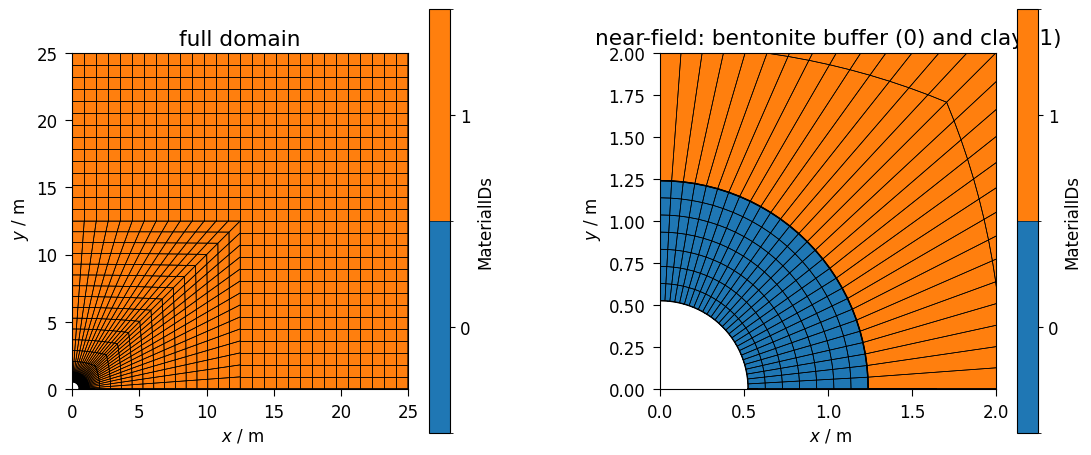

In [7]:
domain = pv.read(mesh_dir / "domain.vtu")
fig, axes = plot_contours(
    domain, ["MaterialIDs"] * 2, cmap="tab10", show_edges=True, zoom=None
)
axes[0].set_title("full domain")
axes[1].set_xlim(0, 2)
axes[1].set_ylim(0, 2)
axes[1].set_title("near-field: bentonite buffer (0) and clay (1)")

### 5. Project generation

`PrjGenerator` assembles the THERMO_RICHARDS_MECHANICS project (fully
saturated TRM-S variant) from the parameters above and writes
`trm_tunnel.prj`.

In [8]:
def clay_with_bedding(angle):
    """Assemble the clay permeability tensor for the bedding angle.

    Only the permeability needs per-case ordering: OGS treats it as a
    global tensor, while the thermal conductivity (solid phase) and the
    orthotropic elasticity are given in the local basis (e0, e1) and
    are rotated with the bedding automatically."""
    k_perp, k_para = CLAY["permeability_perp"], CLAY["permeability_para"]
    if angle == 90:
        permeability = f"{k_perp} 0 0 {k_para}"
    else:
        permeability = f"{k_para} 0 0 {k_perp}"
    return {**CLAY, "permeability": permeability}


projects = {}
for case, config in CASES.items():
    saturation_model = config["saturation_model"]
    prj_generator = PrjGenerator(
        mesh_dir=Path(),  # mesh files are selected through OGS -m
        element_order=ELEMENT_ORDER,
        saturation_model=saturation_model,
        bedding_angle_deg=config["bedding_angle"],
        tunnel_radius=TUNNEL_RADIUS,
        liquid=(LIQUID if saturation_model == "saturated"
                else LIQUID_UNSATURATED),
        bentonite=BENTONITE,
        clay=clay_with_bedding(config["bedding_angle"]),
        biot_coefficient=BIOT_COEFFICIENT,
        heater_flux=HEATER_FLUX,
        initial_temperature=INITIAL_TEMPERATURE,
        initial_pressure=INITIAL_PRESSURE,
        initial_stress=INITIAL_STRESS,
        t_end=T_END,
        initial_dt=INITIAL_DT,
        minimum_dt=MINIMUM_DT,
        maximum_dt=MAXIMUM_DT,
        number_iterations=NUMBER_ITERATIONS,
        multiplier=MULTIPLIER,
        reltols=RELTOLS,
        nonlinear_max_iter=NONLINEAR_MAX_ITER,
        output_prefix=f"trm_tunnel_{case}",
        **linear_solver_options,
    )
    projects[case] = prj_generator.generate_project(
        output_file=prj_dir / f"trm_tunnel_{case}.prj"
    )
    print(f"Generated: {prj_dir / f'trm_tunnel_{case}.prj'}")

Generated: _prj/trm_tunnel_saturated_0.prj
Generated: _prj/trm_tunnel_saturated_90.prj
Generated: _prj/trm_tunnel_partially_saturated.prj


#### Boundary conditions

As in the Kirsch example, `ot.Model.plot_constraints` visualizes the
generated project: the heater surface (`arc_inner`) is fixed and carries
the heat-flux Neumann condition, all outer boundaries are rollers, and
the hydraulic and remaining thermal boundaries are natural (no flow).
The colours distinguish the two materials (0 = bentonite buffer,
1 = Opalinus Clay).

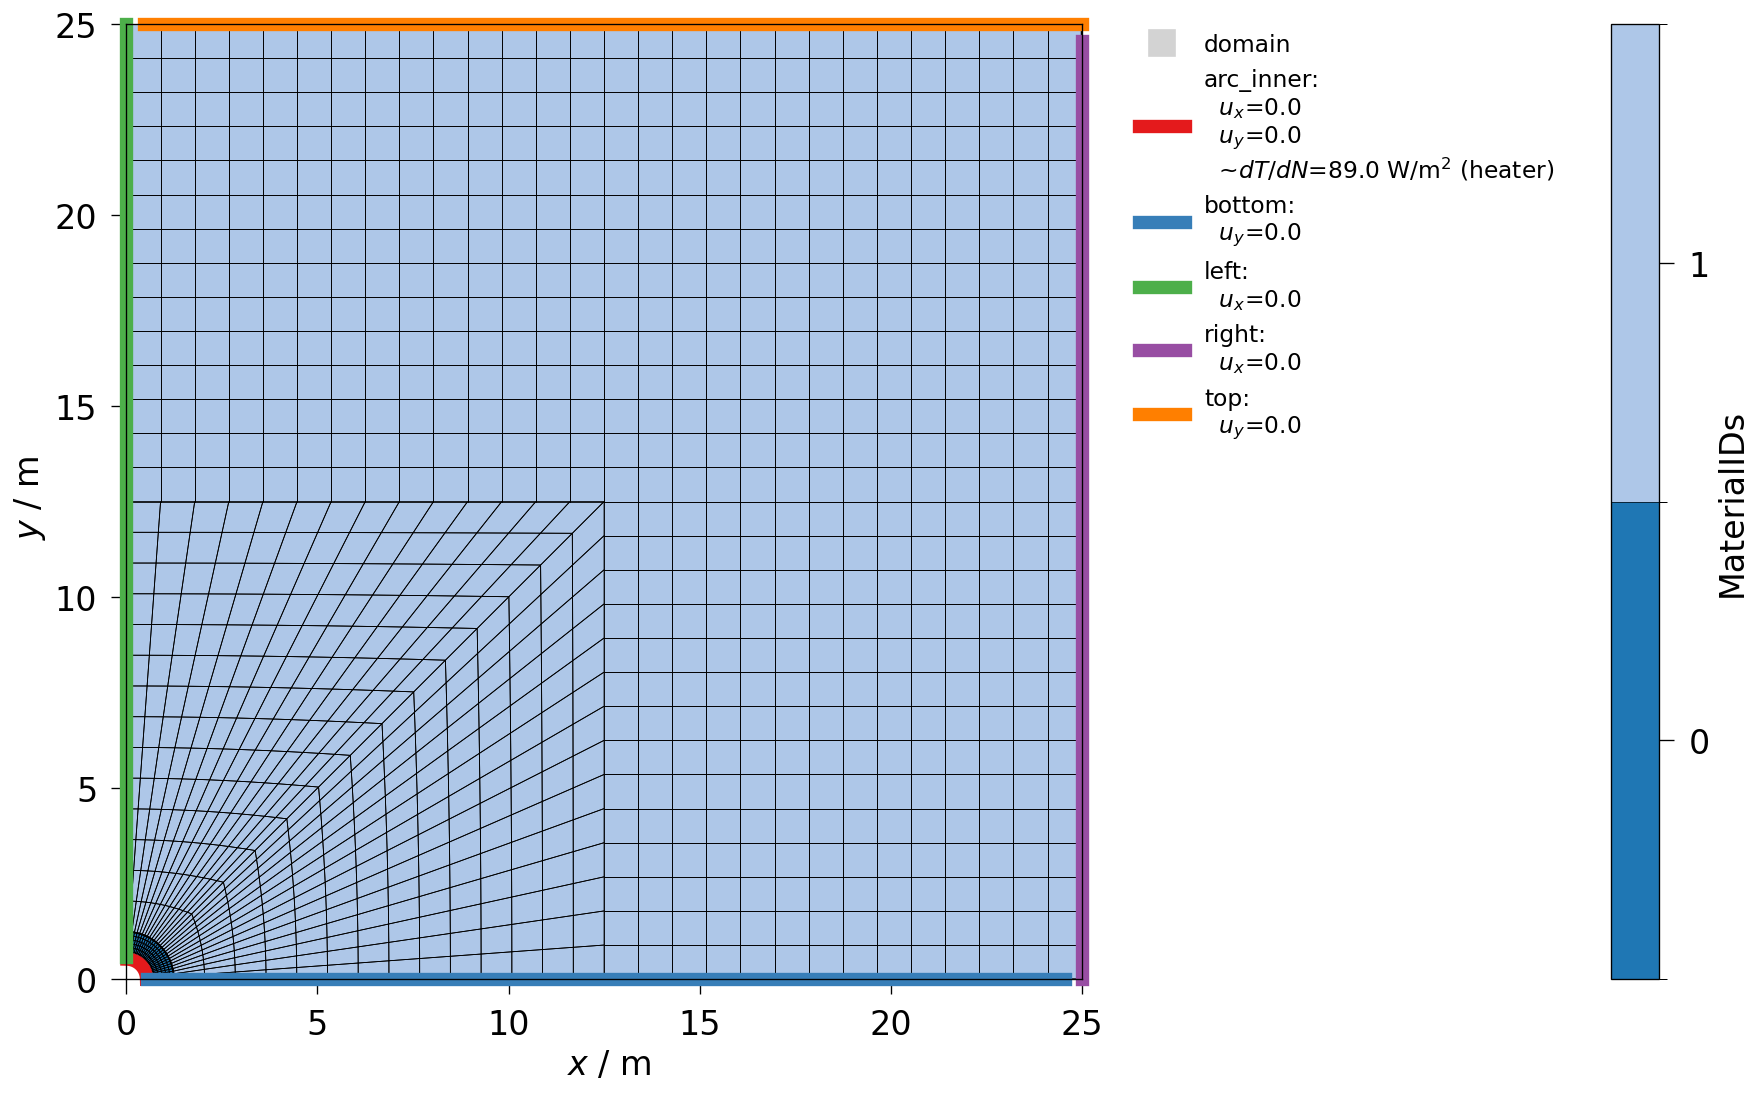

In [9]:
m = ot.Model(project=projects["saturated_90"], meshes=mesh_dir)
fig = m.plot_constraints(figsize=(16, 9), fontsize=20, leg_fontsize=14)
ax = fig.axes[0]
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    if "dN" in label:
        text.set_text(label + " W/m$^2$ (heater)")

### 6. Computation

In [10]:
for case, prj in projects.items():
    print(f"Running OGS: {case} ...")
    prj.run_model(
        logfile=Path(out_dir, f"ogs_{case}.log"),
        args=f"-m {mesh_dir} -o {out_dir}",
    )
    print(f"Results ({case}): {Path(out_dir, f'trm_tunnel_{case}.pvd')}")


Running OGS: saturated_0 ...
 ogs -m input_meshes_trm -o _out _prj/trm_tunnel_saturated_0.prj
['ogs', '-m', 'input_meshes_trm', '-o', '_out', '_prj/trm_tunnel_saturated_0.prj']


Results (saturated_0): _out/trm_tunnel_saturated_0.pvd
Running OGS: saturated_90 ...
 ogs -m input_meshes_trm -o _out _prj/trm_tunnel_saturated_90.prj
['ogs', '-m', 'input_meshes_trm', '-o', '_out', '_prj/trm_tunnel_saturated_90.prj']


Results (saturated_90): _out/trm_tunnel_saturated_90.pvd
Running OGS: partially_saturated ...
 ogs -m input_meshes_trm -o _out _prj/trm_tunnel_partially_saturated.prj
['ogs', '-m', 'input_meshes_trm', '-o', '_out', '_prj/trm_tunnel_partially_saturated.prj']


Results (partially_saturated): _out/trm_tunnel_partially_saturated.pvd


### 7. Results — fully saturated cases

Temperature and liquid pressure at monitoring points, and the
near-field fields at the end of the 5-year heating phase, shown for
the legacy **90° bedding** run (the 0° run is compared against it
below). In the fully
saturated case $S_L = 1$ throughout (the saturation plots are therefore
omitted), and the response shows the classic thermal pressurisation of
the pore water.

The plotted liquid pressures include a **+2 MPa shift**, emulating the
paper's in-situ initial pore pressure (the legacy initial condition used
here starts from $p_0 = 0$; since the fully saturated response is linear
in the pressure level, the shift is exact).

  0%|          | 0/140 [00:00<?, ?it/s]

  9%|▉         | 13/140 [00:00<00:01, 122.86it/s]

 19%|█▊        | 26/140 [00:00<00:00, 117.39it/s]

 27%|██▋       | 38/140 [00:00<00:00, 114.04it/s]

 36%|███▌      | 50/140 [00:00<00:00, 111.23it/s]

...

 76%|███████▌  | 106/140 [00:00<00:00, 106.91it/s]

 84%|████████▎ | 117/140 [00:01<00:00, 105.98it/s]

 91%|█████████▏| 128/140 [00:01<00:00, 106.26it/s]

 99%|█████████▉| 139/140 [00:01<00:00, 106.31it/s]

100%|██████████| 140/140 [00:01<00:00, 108.11it/s]

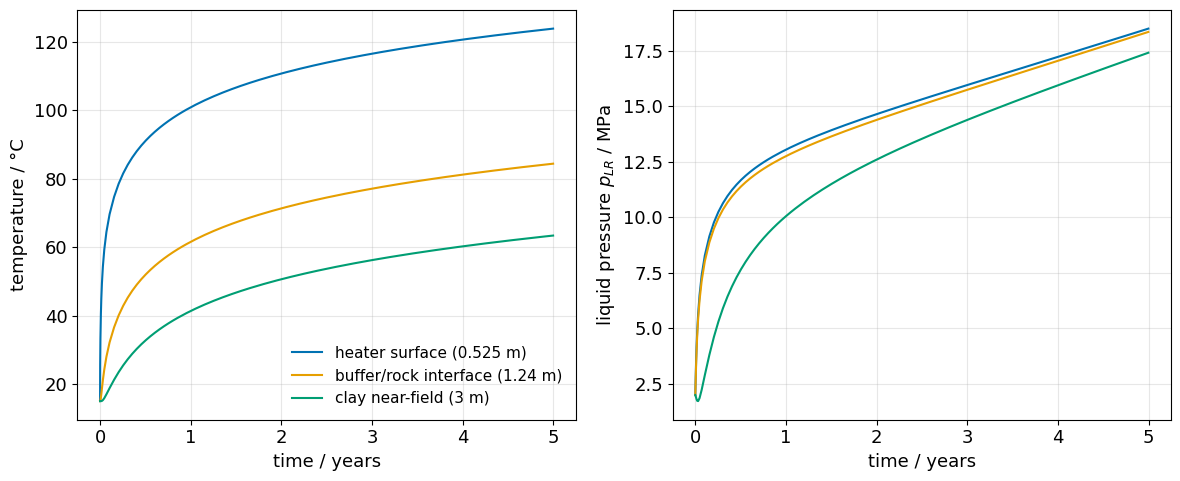

In [11]:
points = {
    "heater surface (0.525 m)": (HEATER_RADIUS, 0.0, 0.0),
    "buffer/rock interface (1.24 m)": (TUNNEL_RADIUS, 0.0, 0.0),
    "clay near-field (3 m)": (3.0, 0.0, 0.0),
}
pts = np.array(list(points.values()))


def load_case(case):
    return ot.MeshSeries(Path(out_dir, f"trm_tunnel_{case}.pvd"))


def plot_histories(ms, show_saturation=True, pressure_offset=0.0):
    probed = ms.probe(pts)
    temperature = probed.values("temperature_interpolated")
    pressure = probed.values("pressure_interpolated") + pressure_offset
    n_panels = 3 if show_saturation else 2
    fig, axs = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    for i, label in enumerate(points):
        t_years = ms.timevalues / (365.25 * 24 * 3600)
        axs[0].plot(t_years, temperature[:, i] - 273.15, label=label)
        axs[1].plot(t_years, pressure[:, i] / 1e6, label=label)
    axs[0].set_ylabel("temperature / \u00b0C")
    axs[1].set_ylabel("liquid pressure $p_{LR}$ / MPa")
    if show_saturation:
        saturation = probed.values("saturation")
        for i, label in enumerate(points):
            axs[2].plot(t_years, saturation[:, i], label=label)
        axs[2].set_ylabel("liquid saturation $S_L$ / -")
    for ax in axs:
        ax.set_xlabel("time / years")
        ax.grid(alpha=0.3)
    axs[0].legend(fontsize=11)
    fig.tight_layout()


def plot_fields(ms, show_saturation=True, pressure_offset=0.0):
    # Work on a copy: MeshSeries caches its meshes, and in-place edits
    # would leak into later cells that read the same series.
    last = ms.mesh(-1).copy()
    # Saturation is extrapolated from integration points to nodes for
    # output, which can overshoot slightly at the S_L = 1 plateau; clip.
    last.point_data["saturation"] = np.clip(
        last.point_data["saturation"], 0.0, 1.0
    )
    last.point_data["pressure_interpolated"] = (
        last.point_data["pressure_interpolated"] + pressure_offset
    )
    variables = [
        ot.variables.temperature.replace(
            data_name="temperature_interpolated"
        ),
        ot.variables.pressure.replace(data_name="pressure_interpolated"),
    ]
    if show_saturation:
        variables.append(ot.variables.saturation)
    plot_contours(last, variables)


def plot_case_histories(cases, pressure_offset=0.0):
    """Overlay the T/p histories of several runs at the monitoring points."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    styles = ["-", "--", ":"]
    for (case_label, ms), style in zip(cases.items(), styles):
        probed = ms.probe(pts)
        temperature = probed.values("temperature_interpolated")
        pressure = probed.values("pressure_interpolated") + pressure_offset
        t_years = ms.timevalues / (365.25 * 24 * 3600)
        for i, label in enumerate(points):
            axs[0].plot(t_years, temperature[:, i] - 273.15, style,
                        color=f"C{i}", label=f"{label}, {case_label}")
            axs[1].plot(t_years, pressure[:, i] / 1e6, style, color=f"C{i}")
    axs[0].set_ylabel("temperature / \u00b0C")
    axs[1].set_ylabel("liquid pressure $p_{LR}$ / MPa")
    for ax in axs:
        ax.set_xlabel("time / years")
        ax.grid(alpha=0.3)
    axs[0].legend(fontsize=9)
    fig.tight_layout()


def plot_field_comparison(cases, variable, zoom=10.0):
    """Contour one field of several runs side by side (final time step)."""
    fig, axes = plt.subplots(
        1, len(cases), figsize=(6.5 * len(cases), 5.5),
        gridspec_kw={"wspace": 0.4},
    )
    for axis, (case_label, ms) in zip(np.atleast_1d(axes), cases.items()):
        ot.plot.contourf(ms.mesh(-1), variable, fig=fig, ax=axis,
                         fontsize=12, cb_labelsize=12, cmap=CMAP_FIELD)
        axis.set_title(case_label, fontsize=13)
        axis.set_xlim(0, zoom)
        axis.set_ylim(0, zoom)


def plot_boundary_displacements(cases):
    """u_x along the bottom boundary (y = 0) and u_y along the left
    boundary (x = 0): the free (roller-tangential) displacement of the
    two symmetry planes."""
    profiles = (
        (1, 0, "$x$ / m", "$u_x$ along the bottom boundary / mm"),
        (0, 1, "$y$ / m", "$u_y$ along the left boundary / mm"),
    )
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    styles = ["-", "--", ":"]
    for ax, (zero_coord, component, xlabel, ylabel) in zip(axs, profiles):
        for (case_label, ms), style in zip(cases.items(), styles):
            mesh = ms.mesh(-1)
            on_boundary = np.isclose(mesh.points[:, zero_coord], 0.0)
            s = mesh.points[on_boundary, 1 - zero_coord]
            u = mesh.point_data["displacement"][on_boundary, component]
            order = np.argsort(s)
            ax.plot(s[order], u[order] * 1000, style, label=case_label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=11)
    fig.tight_layout()


# Observation points on the bottom boundary: heater surface, buffer/rock
# interface, and four points in the clay.
observation_points = {
    f"{r} m": (r, 0.0, 0.0) for r in (0.525, 1.24, 5.0, 10.0, 15.0, 20.0)
}


def plot_observation_histories(cases, pressure_offset=0.0):
    """u_x and liquid-pressure histories at the bottom-boundary
    observation points, probed and plotted as in the Kirsch example."""
    obs_pts = np.asarray(list(observation_points.values()))
    u_x = ot.variables.displacement["x"].replace(output_unit="mm")
    p_LR = ot.variables.pressure.replace(data_name="pressure_interpolated")
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    styles = ["-", "--", ":"]
    for (case_label, ms), style in zip(cases.items(), styles):
        extracted = ot.MeshSeries.probe(ms, obs_pts).scale(time="a")
        for mesh in extracted:
            mesh["pressure_interpolated"] = (
                mesh["pressure_interpolated"] + pressure_offset
            )
        labels = [f"{point}, {case_label}" for point in observation_points]
        ot.plot.line(extracted, "time", u_x, ax=axs[0], labels=labels,
                     fontsize=11, ls=style)
        ot.plot.line(extracted, "time", p_LR, ax=axs[1], labels=labels,
                     fontsize=11, ls=style)
    for ax in axs:
        ax.grid(alpha=0.3)
    axs[0].legend(fontsize=8, ncol=len(cases))
    axs[1].get_legend().remove()
    fig.tight_layout()


ms_saturated_0 = load_case("saturated_0")
ms_saturated_90 = load_case("saturated_90")
# +2 MPa emulates the paper's in-situ initial pore pressure (our legacy
# IC starts at 0; the saturated response is linear in the pressure level).
plot_histories(ms_saturated_90, show_saturation=False, pressure_offset=2.0e6)

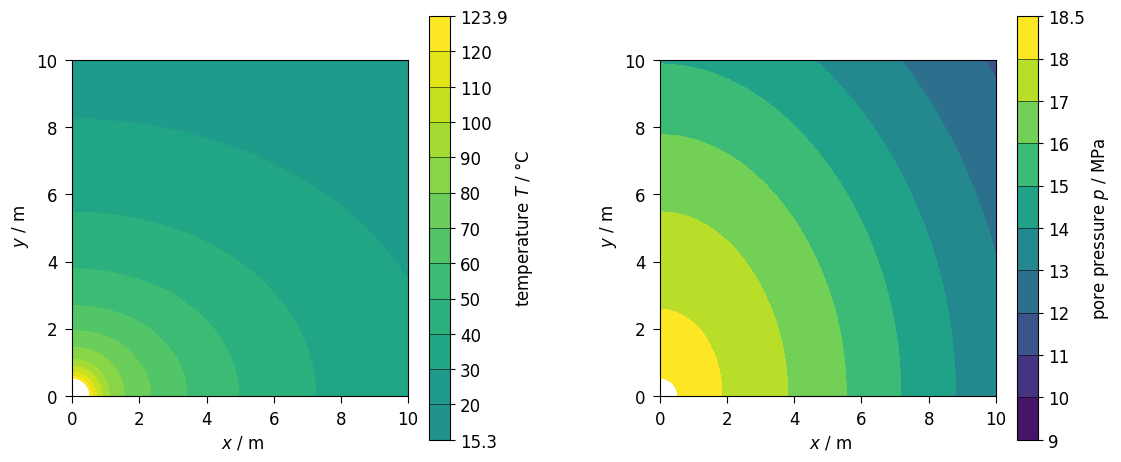

In [12]:
plot_fields(ms_saturated_90, show_saturation=False, pressure_offset=2.0e6)

#### Effect of the bedding orientation (0° vs. 90°)

The two fully saturated runs are exact 90° rotations of each other:
the local coordinate system (which orients the orthotropic elasticity
and the clay's thermal conductivity) and the global permeability tensor
are rotated together. Since the monitoring points lie on the $x$-axis,
the two runs sample the two principal directions of the anisotropic
material response — visible as faster/slower drainage in the pressure
histories and as the rotating elongated thermal halo in the contours.
The tangential displacements along the two symmetry planes — $u_x$
on the bottom boundary and $u_y$ on the left boundary (both rollers) —
additionally show the orthotropic elasticity: the soft axis
($E = 4$ GPa) lies along $x$ in one orientation and along $y$ in the
other. Because the two runs are 90° rotations of each other, the
$u_y$ profile of one case coincides with the $u_x$ profile of the
other.

  0%|          | 0/140 [00:00<?, ?it/s]

  9%|▉         | 13/140 [00:00<00:01, 124.81it/s]

 19%|█▊        | 26/140 [00:00<00:00, 117.01it/s]

 27%|██▋       | 38/140 [00:00<00:00, 114.87it/s]

 36%|███▌      | 50/140 [00:00<00:00, 111.92it/s]

...

 76%|███████▌  | 106/140 [00:00<00:00, 107.77it/s]

 84%|████████▎ | 117/140 [00:01<00:00, 107.77it/s]

 91%|█████████▏| 128/140 [00:01<00:00, 107.21it/s]

 99%|█████████▉| 139/140 [00:01<00:00, 105.63it/s]

100%|██████████| 140/140 [00:01<00:00, 108.60it/s]

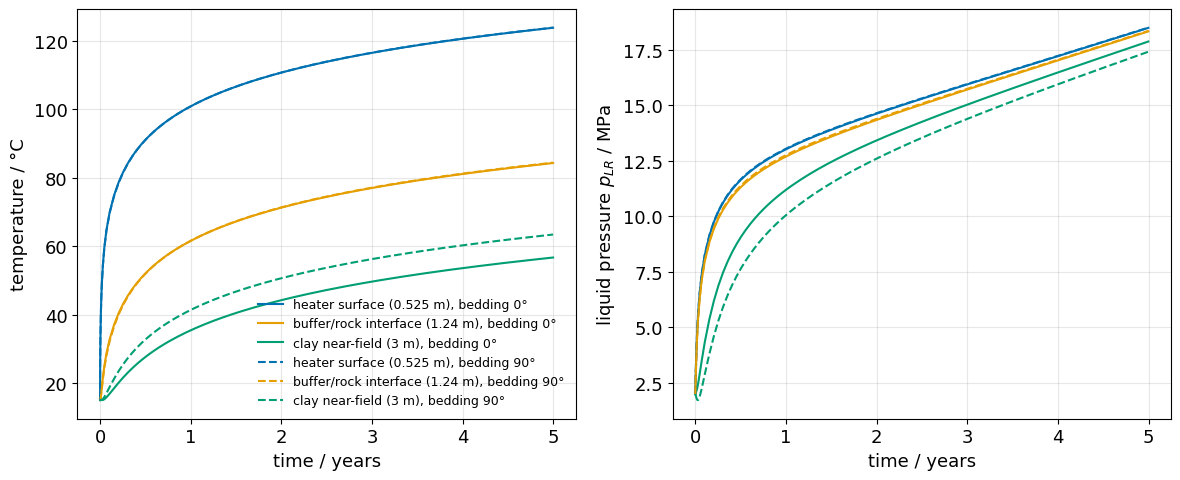

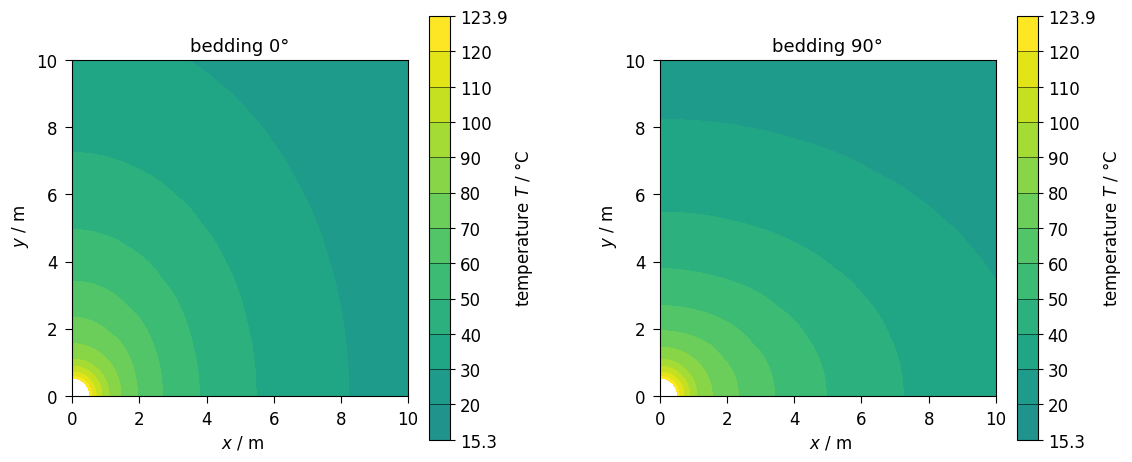

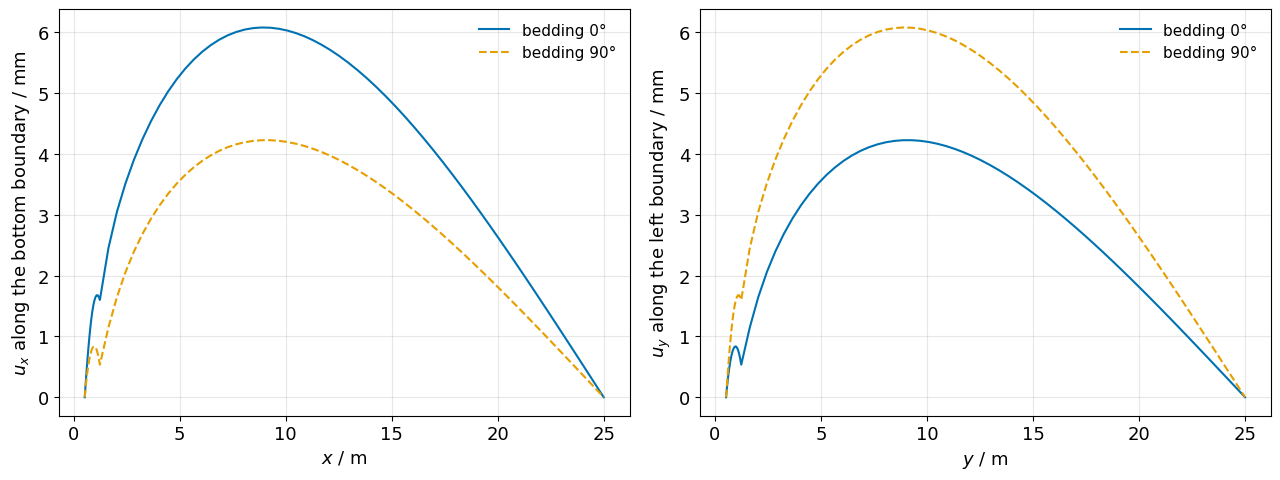

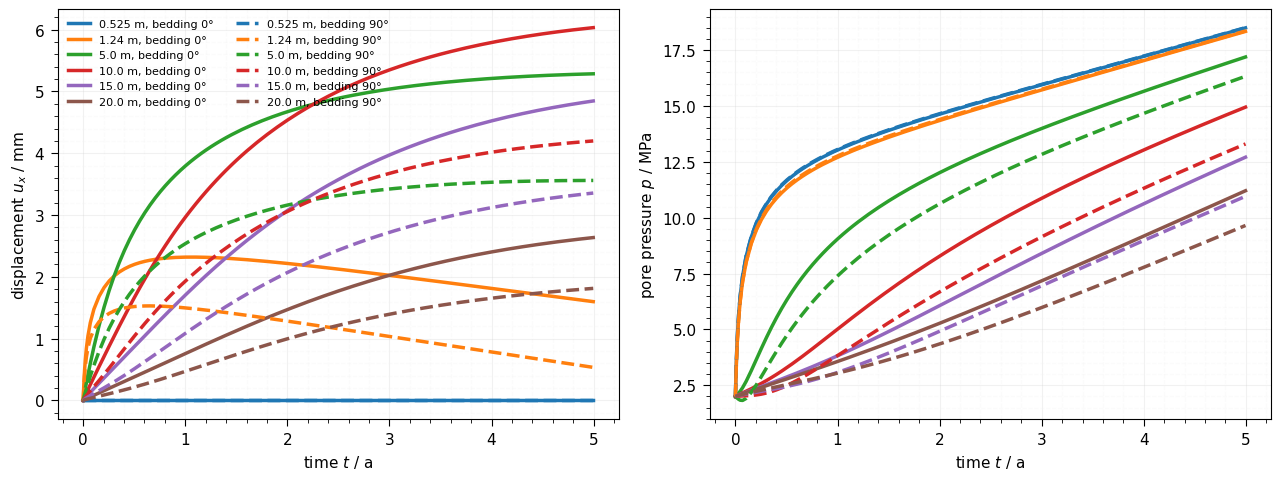

In [13]:
saturated_cases = {"bedding 0\u00b0": ms_saturated_0,
                   "bedding 90\u00b0": ms_saturated_90}
plot_case_histories(saturated_cases, pressure_offset=2.0e6)
plot_field_comparison(
    saturated_cases,
    ot.variables.temperature.replace(data_name="temperature_interpolated"),
)
plot_boundary_displacements(saturated_cases)
plot_observation_histories(saturated_cases, pressure_offset=2.0e6)

### 8. Results — partially saturated case

The same evaluation for the partially saturated model (van Genuchten
retention, water-vapour diffusion): the buffer starts at high suction
($S_L = 0.23$), dries out further near the heater, and slowly resaturates
with water drawn from the host rock.

  0%|          | 0/143 [00:00<?, ?it/s]

  9%|▉         | 13/143 [00:00<00:01, 125.26it/s]

 18%|█▊        | 26/143 [00:00<00:00, 119.28it/s]

 27%|██▋       | 38/143 [00:00<00:00, 115.48it/s]

 35%|███▍      | 50/143 [00:00<00:00, 112.47it/s]

...

 74%|███████▍  | 106/143 [00:00<00:00, 106.23it/s]

 82%|████████▏ | 117/143 [00:01<00:00, 106.43it/s]

 90%|████████▉ | 128/143 [00:01<00:00, 105.96it/s]

 97%|█████████▋| 139/143 [00:01<00:00, 104.15it/s]

100%|██████████| 143/143 [00:01<00:00, 107.71it/s]

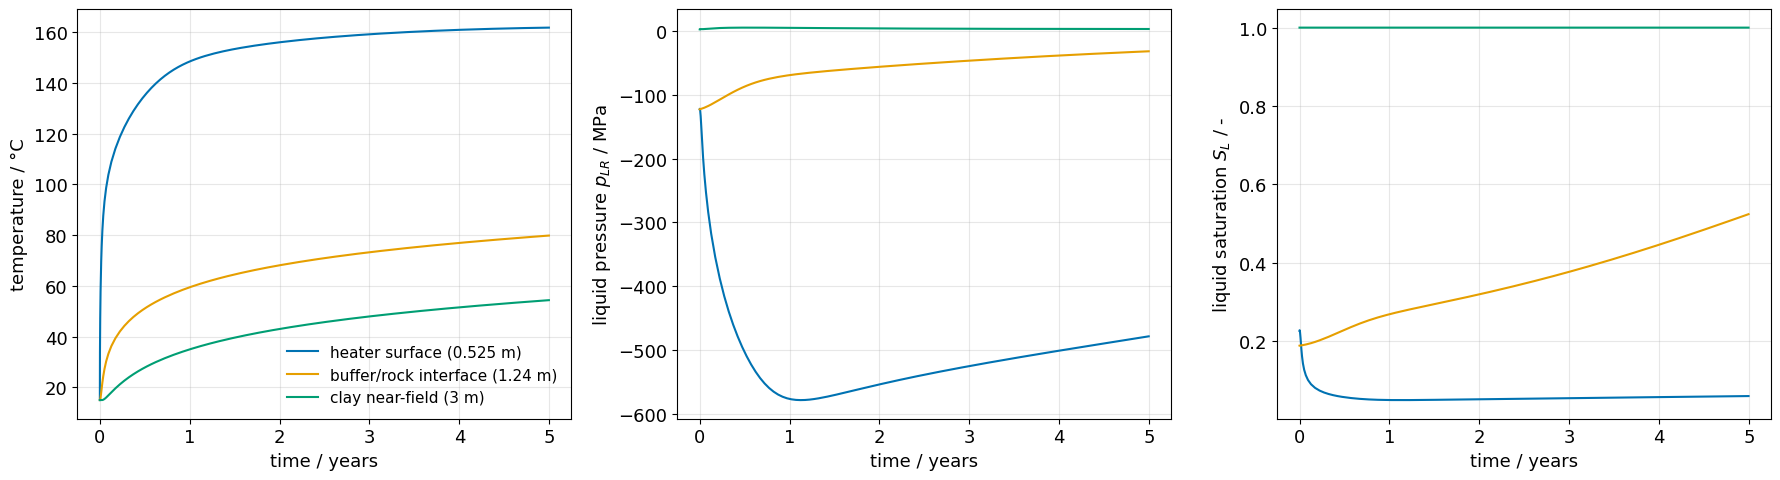

In [14]:
ms_partially_saturated = load_case("partially_saturated")
plot_histories(ms_partially_saturated)

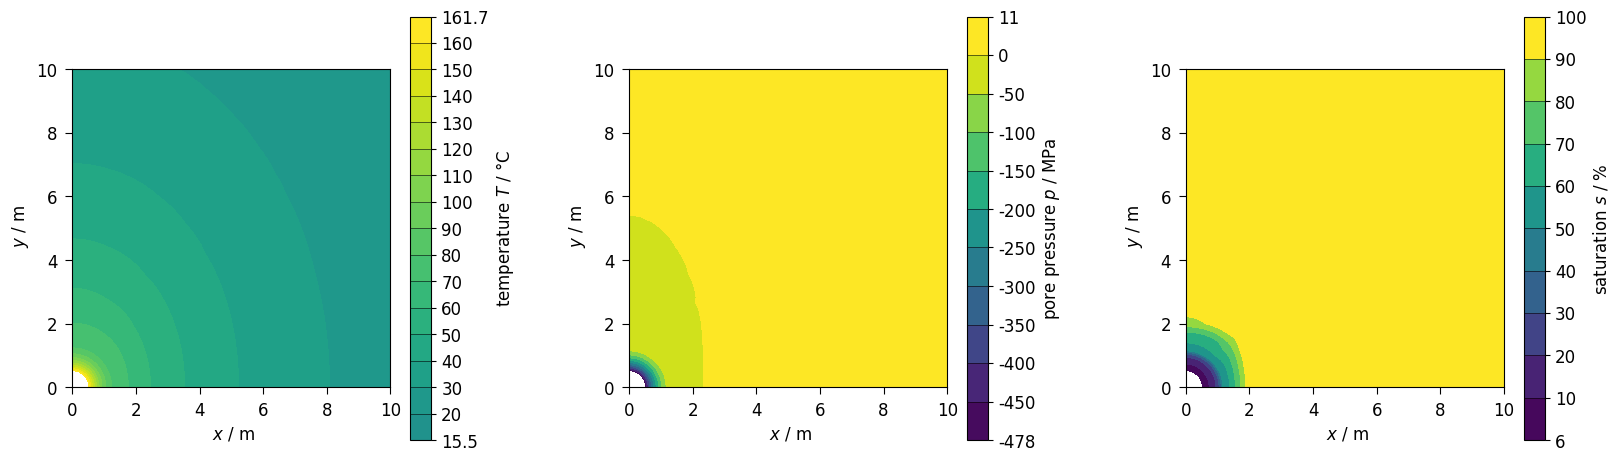

In [15]:
plot_fields(ms_partially_saturated)

#### Mechanical response (partially saturated case): displacement and stress measures

The mechanical response is summarized in a 2×2 figure: the
**displacement magnitude** $\|\boldsymbol{u}\|$ together with the
**effective mean stress** $\sigma'_m = \sigma_m + p$ (Biot coefficient 1,
tension positive) in the first row, and the two stress invariants that
dilatancy-type integrity criteria are built from in the second row:

- the **octahedral shear stress**, the shear-stress measure driving
  dilatancy and damage:

$$
\tau_\mathrm{oct} = \frac{1}{3}\sqrt{(\sigma_I-\sigma_{II})^2 + (\sigma_{II}-\sigma_{III})^2 + (\sigma_{III}-\sigma_I)^2} = \sqrt{\tfrac{2}{3}\,J_2}\,;
$$

- the **mean (total) stress** (tension positive, so compression is
  negative):

$$
\sigma_m = \tfrac{1}{3}\operatorname{tr}\boldsymbol{\sigma}\,.
$$

These invariants require no material-specific constants and can be
compared with any dilatancy boundary afterwards. The comparison of
$\sigma_m$ and $\sigma'_m$ shows the key effect: the thermal
pressurisation (up to $\approx 16$ MPa of pore pressure) consumes the
compressive confinement, so $\sigma'_m$ approaches zero or even tension
near the heater — the state in which shear-induced dilatancy and
hydraulic fracturing become possible.
The boundary profiles ($u_x$ along the bottom, $u_y$ along the left
boundary) complement the field plots; with the 90° bedding they differ
because the soft elastic axis lies along one of the two symmetry planes.

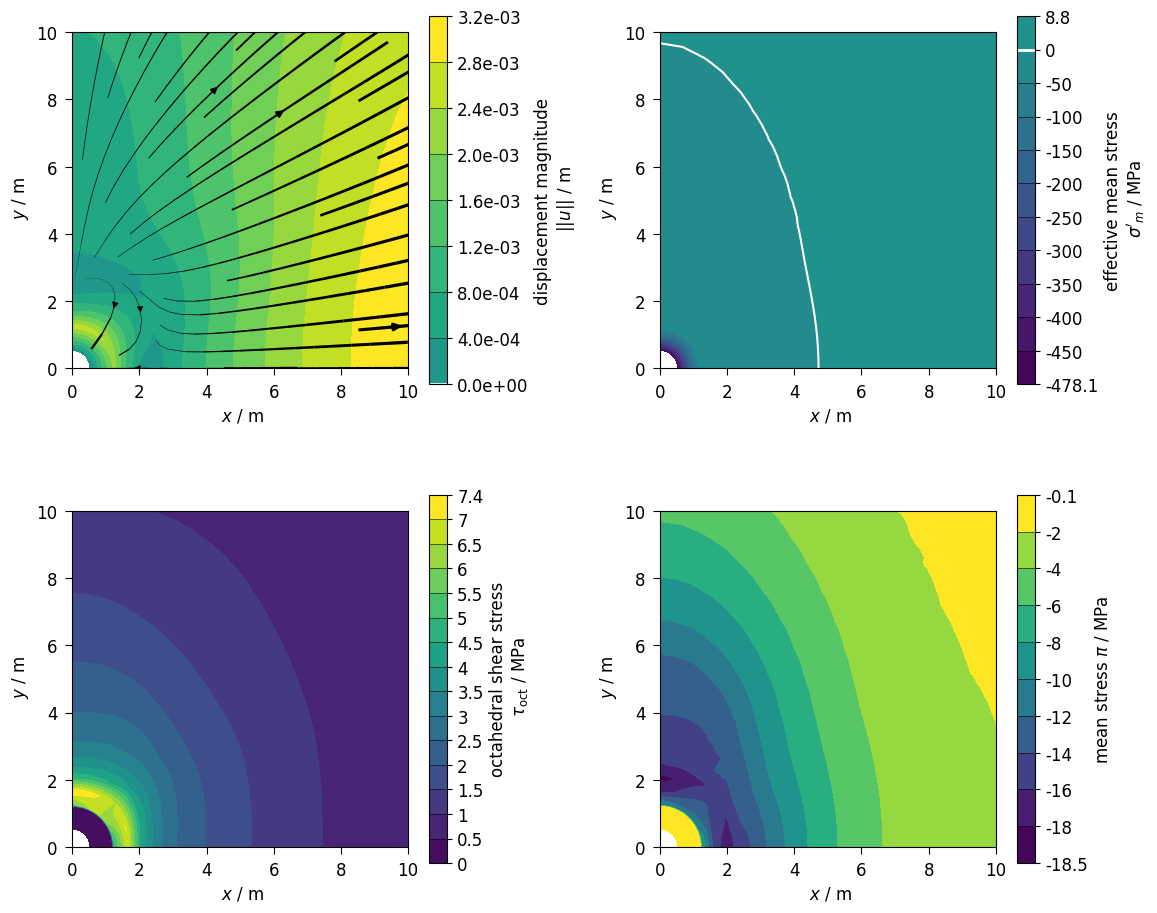

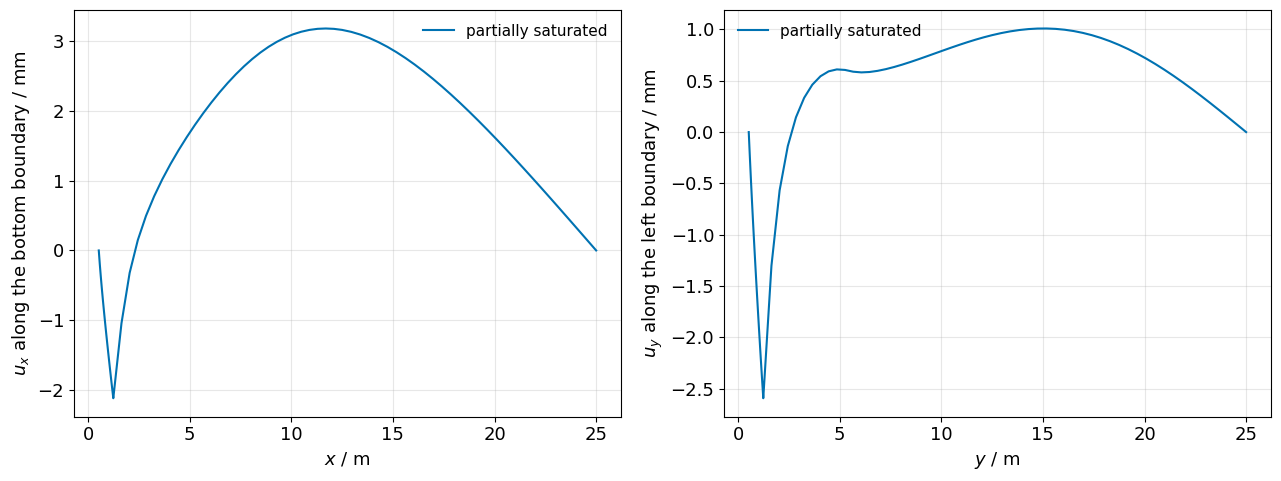

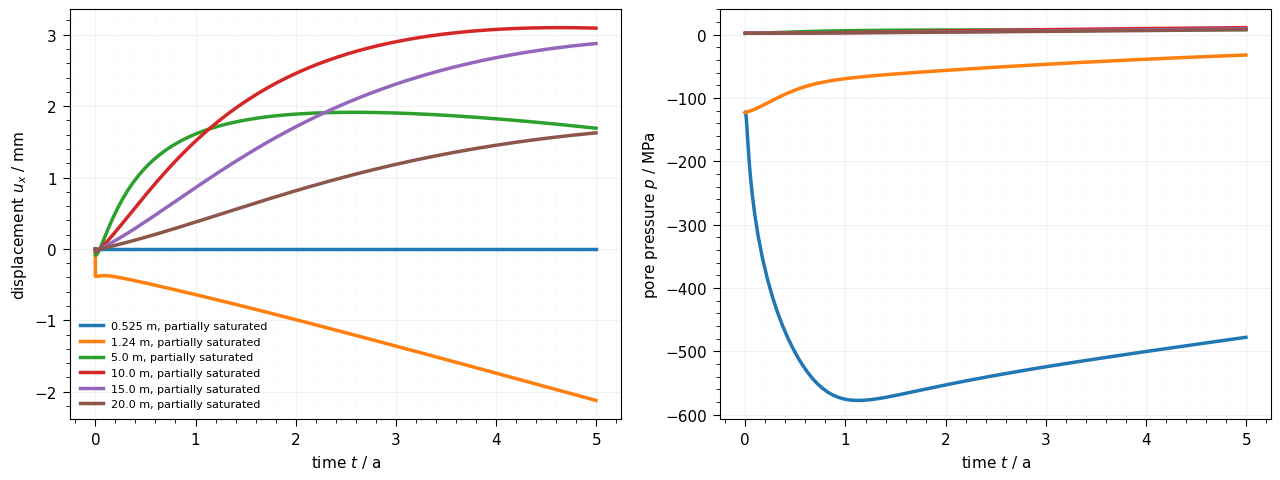

In [16]:
plot_mechanics(ms_partially_saturated)
plot_boundary_displacements({"partially saturated": ms_partially_saturated})
plot_observation_histories({"partially saturated": ms_partially_saturated})

# References
[1] M. Pitz, S. Kaiser, N. Grunwald, V. Kumar, J. Buchwald, W. Wang, D. Naumov, A. A. Chaudhry, J. Maßmann, J. Thiedau, O. Kolditz, T. Nagel, “Non-isothermal consolidation: A systematic evaluation of two implementations based on multiphase and Richards equations,” Int. J. Rock Mech. Min. Sci., 170 (2023), 105534. https://doi.org/10.1016/j.ijrmms.2023.105534

[2] M. A. Biot, “General theory of three-dimensional consolidation,” J. Appl. Phys., 12(2) (1941), 155–164. https://doi.org/10.1063/1.1712886

[3] R. W. Lewis, B. A. Schrefler, The Finite Element Method in the Static and Dynamic Deformation and Consolidation of Porous Media, 2nd ed., John Wiley & Sons, Chichester, 1998.